In [2]:
import os
print(os.getcwd())

#words = open('~/Documents/ml_dl_frame_work/makemore-project/names.txt').read().splitlines()
words = open('names.txt').read().splitlines()



/home/lenovo/Documents/ml_dl_frame_work/makemore-project


In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [8]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

In [17]:
b={}
for w in words:
    chs = ['<S>'] + list(w) +  ['<E>']
    for ch1 , ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0)+1
        #print(ch1,ch2)

In [22]:
sorted(b.items(), key = lambda kv : -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [43]:
#Let's convert the dict to multi-dim array
import torch 

N = torch.zeros((27,27), dtype=torch.int32)



In [58]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i ,s in enumerate(chars)}
stoi['.']= 0



In [59]:
for w in words:
    chs = ['.'] + list(w) +  ['.']
    for ch1 , ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1 , ix2] += 1

In [69]:
import string
chars = list(string.ascii_lowercase) + ['.']
itos ={i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

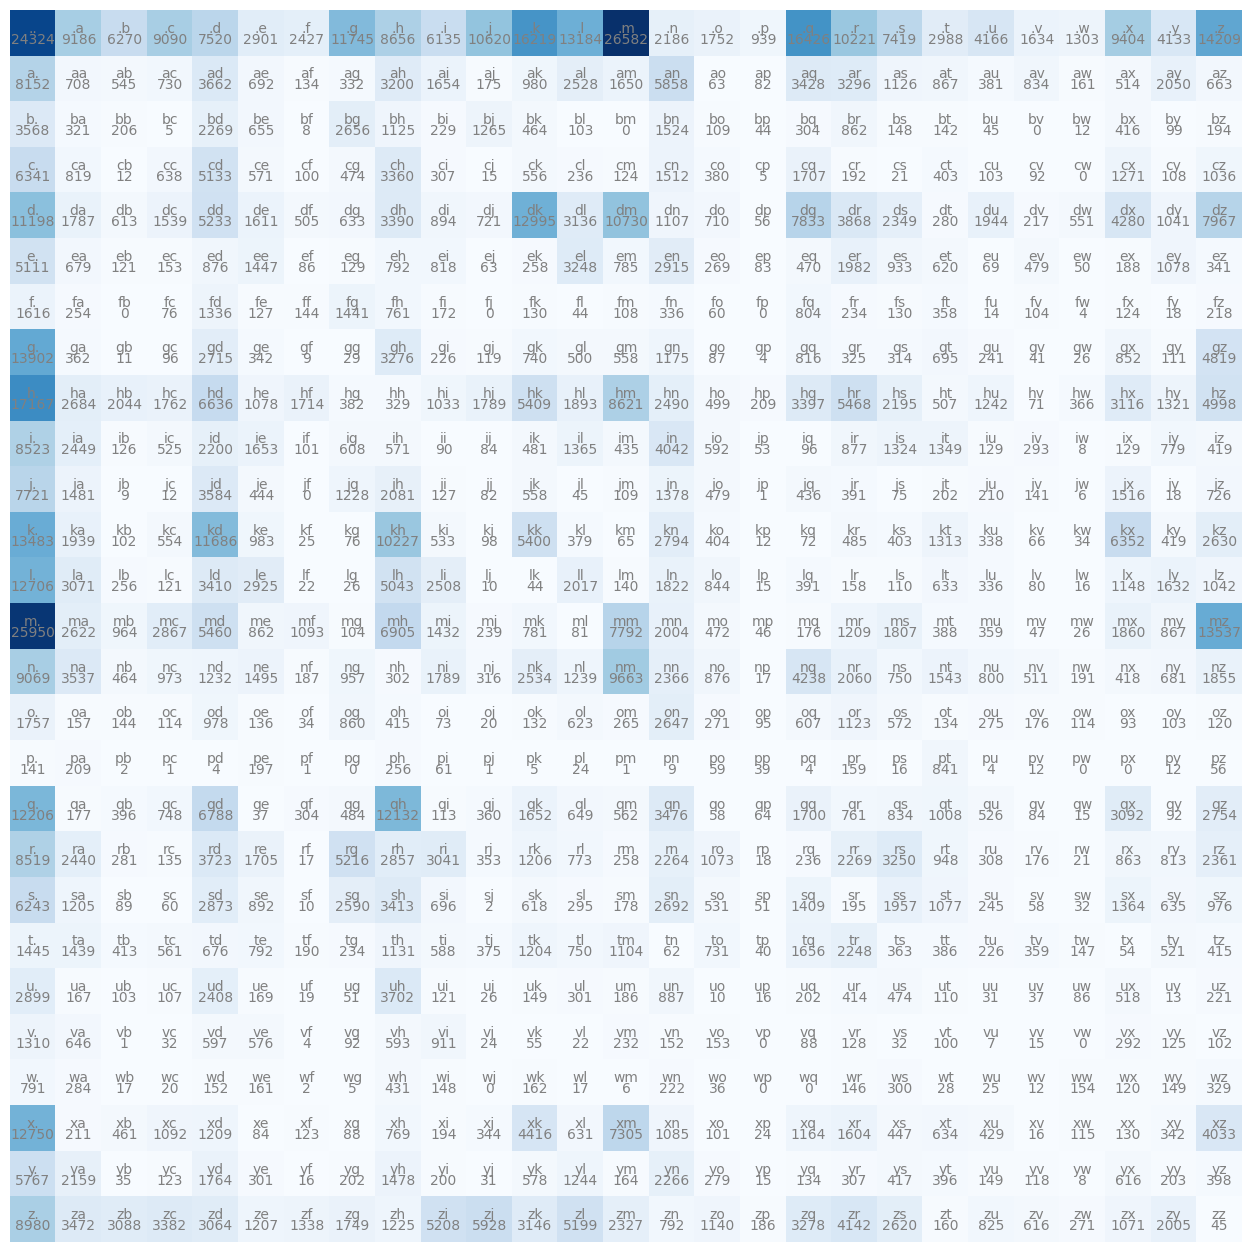

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(16,16))
plt.imshow(N , cmap= 'Blues')
for i in range(27):
    for j in range(27):
        chstr  = itos[i] + itos[j]
        plt.text(j,i,chstr,ha="center" , color ='gray')
        plt.text(j,i,N[i,j].item(), ha ="center", va="top",color = "gray")
plt.axis("off")        

In [71]:
N[0]

tensor([24324,  9186,  6270,  9090,  7520,  2901,  2427, 11745,  8656,  6135,
        10620, 16219, 13184, 26582,  2186,  1752,   939, 16426, 10221,  7419,
         2988,  4166,  1634,  1303,  9404,  4133, 14209], dtype=torch.int32)

In [72]:
p = N[0].float()
p= p/p.sum()
p

tensor([0.1050, 0.0397, 0.0271, 0.0392, 0.0325, 0.0125, 0.0105, 0.0507, 0.0374,
        0.0265, 0.0458, 0.0700, 0.0569, 0.1148, 0.0094, 0.0076, 0.0041, 0.0709,
        0.0441, 0.0320, 0.0129, 0.0180, 0.0071, 0.0056, 0.0406, 0.0178, 0.0613])